# 0. Build the CNN input files from raw SMP data

Turns one campaign's raw SnowMicroPen (SMP) field data into the two NetCDF
files the rest of this repo works with: a fine-resolution per-campaign file,
and the depth-bin feature file that `01_training.ipynb`/`02_inference.ipynb`
read directly.

Expects a campaign directory laid out the way the SMP field software writes
it: one folder per station (e.g. `PS111_20180211_3-2_SMP`), each with one or
more `*TRANS*` transect folders holding a tab-separated `*_ini.txt` table and
a `_raw`/`raw` folder of `.pnt` profiles. A matching snowpit directory holds
one `*META.txt` per station.

Uses PS111 as the example campaign — the same campaign `02_inference.ipynb`
already classifies by default (`config.UNLABELLED_DATA`) — so this reproduces
the shipped `data/unlabelled/PS111_profiles.nc` from the campaign's raw data,
rather than replacing it: the output below is written under a different name,
and `02_inference.ipynb` needs no changes to run on PS111. A labelled
campaign (raw profiles with hand-drawn layer markers) produces the same shape
of file, just with `dominant_label` filled in rather than all-NaN.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt

import config
import feature_engineering
import raw_import

## Build the fine-resolution campaign file

Walks every transect under `campaign_dir`, matches each profile to its
snowpit meta, and concatenates everything into one `(profile, sample)`
dataset at full sensor resolution. Needed later to map predictions back onto
the original depth grid, so it stays out of version control (`data/raw/`,
see `.gitignore`) rather than shipping like the feature files below.

In [2]:
campaign_dir = "/home/dariapaul/work/01_proj_smp/data/201801-03_PS111/_data_stations/SMP"
snowpit_dir = "/home/dariapaul/work/01_proj_smp/data/201801-03_PS111/_data_stations/SNOWPIT"

campaign = raw_import.build_campaign_dataset(campaign_dir, snowpit_dir)
print(f"profiles {campaign.sizes['profile']}, samples {campaign.sizes['sample']}")
campaign

Latitude value -99999.0 invalid, replacing by None (file S43M0129)


Longitude value None invalid, replacing by None (file S43M0129)


Latitude value -99999.0 invalid, replacing by None (file S43M0333)


Longitude value None invalid, replacing by None (file S43M0333)


Latitude value -99999.0 invalid, replacing by None (file S43M0339)


...

Longitude value None invalid, replacing by None (file S43M0344)


Latitude value -99999.0 invalid, replacing by None (file S43M0347)


Longitude value None invalid, replacing by None (file S43M0347)


profiles 144, samples 118819


<xarray.Dataset>
Dimensions:         (profile: 144, sample: 118819)
Coordinates:
    time            (profile) datetime64[ns] 2018-02-08T14:19:29 ... 2018-02-...
    lat             (profile) float64 -75.11 -75.11 -75.11 ... -76.85 -76.85
    lon             (profile) float64 -41.81 -41.81 -41.81 ... -35.56 -35.56
    icetype         (profile) <U3 'FYI' 'FYI' 'FYI' 'FYI' ... 'FYI' 'FYI' 'FYI'
Dimensions without coordinates: profile, sample
Data variables: (12/13)
    depth           (profile, sample) float64 0.0 0.004132 0.008264 ... nan nan
    force           (profile, sample) float64 0.02396 0.01766 ... nan nan
    label           (profile, sample) float64 nan nan nan nan ... nan nan nan
    K2020b_density  (profile, sample) float64 231.7 nan nan nan ... nan nan nan
    CR2020_density  (profile, sample) float64 240.6 nan nan nan ... nan nan nan
    CR2020_ssa      (profile, sample) float64 17.42 nan nan nan ... nan nan nan
    ...              ...
    freeboard       (profile) int64 6 6 6 6 6 6 6 6 6 6 ... 2 2 2 2 2 2 2 2 2 2
    name            (profile) <U8 'S43M0003' 'S43M0005' ... 'S43M0392'
    snow_depth      (profile) int64 53 53 49 55 52 51 51 ... 9 5 9 16 20 20 22
    group_id        (profile) <U7 'TRANS01' 'TRANS01' ... 'TRANS01' 'TRANS01'
    location        (profile) float64 1.0 2.0 3.0 4.0 ... 33.0 34.0 35.0 36.0
    training        (profile) bool False False False False ... False False False

In [3]:
raw_path = config.REPO_ROOT / "data" / "raw" / "PS111_profiles.nc"
raw_path.parent.mkdir(parents=True, exist_ok=True)
campaign.to_netcdf(raw_path)
print(f"wrote {raw_path}")

wrote /home/dariapaul/work/01_proj_smp/code_publication/smp-cnn/data/raw/PS111_profiles.nc


## Aggregate into depth-bin features

Groups each profile into 1 mm depth bins and computes the 18 features in
`config.FEATURE_VARS`, plus a `dominant_label` per bin — all-NaN here, since
this walk covers PS111's unlabelled transect profiles (the hand-labelled ones
behind `data/labelled/smp_profiles_labelled.nc` come from a separate,
curated set of profiles next to snow pits).

In [4]:
features = feature_engineering.build_feature_dataset(campaign)

missing = [v for v in config.FEATURE_VARS if v not in features.data_vars]
if missing:
    raise ValueError(f"missing required features: {missing}")

print(f"profiles {features.sizes['profile']}, depth bins {features.sizes['depth_bins']}")
features

profiles 144, depth bins 491


<xarray.Dataset>
Dimensions:                     (depth_bins: 491, profile: 144)
Coordinates:
  * depth_bins                  (depth_bins) int64 0 1 2 3 4 ... 487 488 489 490
    time                        (profile) datetime64[ns] 2018-02-08T14:19:29 ...
    lat                         (profile) float64 -75.11 -75.11 ... -76.85
    lon                         (profile) float64 -41.81 -41.81 ... -35.56
    icetype                     (profile) <U3 'FYI' 'FYI' 'FYI' ... 'FYI' 'FYI'
    name                        (profile) <U8 'S43M0003' ... 'S43M0392'
Dimensions without coordinates: profile
Data variables: (12/19)
    mean_force                  (profile, depth_bins) float64 0.1611 ... nan
    var_force                   (profile, depth_bins) float64 0.0113 ... nan
    min_force                   (profile, depth_bins) float64 0.002522 ... nan
    max_force                   (profile, depth_bins) float64 0.488 ... nan
    distance                    (profile, depth_bins) float64 1.0 2.0 ... nan
    first_derivative            (profile, depth_bins) float64 0.0009901 ... nan
    ...                          ...
    force_median                (profile, depth_bins) float64 0.2434 ... nan
    lambda                      (profile, depth_bins) float64 36.28 39.0 ... nan
    f0                          (profile, depth_bins) float64 0.1933 ... nan
    delta                       (profile, depth_bins) float64 0.07951 ... nan
    L                           (profile, depth_bins) float64 0.815 ... nan
    dominant_label              (profile, depth_bins) float64 nan nan ... nan

## Sanity check

One profile's force trace, at both resolutions.

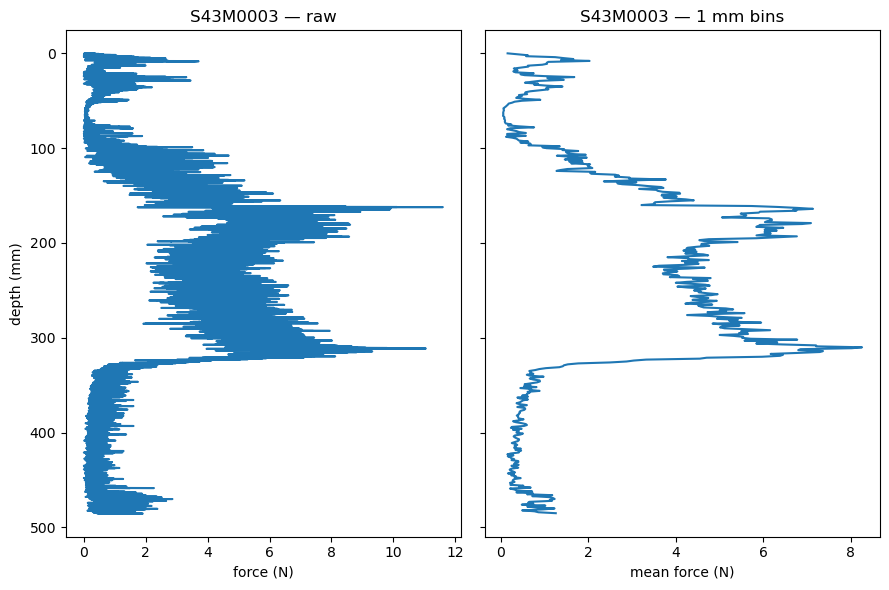

In [5]:
profile_index = 0

figure, (ax_fine, ax_binned) = plt.subplots(1, 2, figsize=(9, 6), sharey=True)

fine_profile = campaign.isel(profile=profile_index)
ax_fine.plot(fine_profile.force, fine_profile.depth)
ax_fine.set_title(f"{fine_profile.name.item()} — raw")
ax_fine.set_xlabel("force (N)")
ax_fine.set_ylabel("depth (mm)")

binned_profile = features.isel(profile=profile_index)
ax_binned.plot(binned_profile.mean_force, binned_profile.depth_bins)
ax_binned.set_title(f"{binned_profile.name.item()} — 1 mm bins")
ax_binned.set_xlabel("mean force (N)")

ax_fine.invert_yaxis()
figure.tight_layout()
plt.show()

## Write the feature file

Written as `PS111_profiles_rebuilt.nc`, next to the shipped
`data/unlabelled/PS111_profiles.nc` rather than over it — this step exists to
demonstrate and validate the preprocessing code, not to replace the shipped
file that `02_inference.ipynb` already uses.

In [6]:
feature_path = config.REPO_ROOT / "data" / "unlabelled" / "PS111_profiles_rebuilt.nc"
features.to_netcdf(feature_path, mode="w", format="NETCDF4", engine="netcdf4")
print(f"wrote {feature_path}")

wrote /home/dariapaul/work/01_proj_smp/code_publication/smp-cnn/data/unlabelled/PS111_profiles_rebuilt.nc
